# 02 — Per-Query Distribution + RAG Results

Two evaluation dimensions beyond the aggregate benchmark:

1. **Per-Query Distribution** — how retrievers perform query-by-query (box plots, head-to-head comparisons).
2. **RAG Results** — answer quality of the retrieve-then-generate pipeline (real TriviaQA subset, HPC).

**Inputs:** `results/{scifact,fiqa,nfcorpus}_per_query.csv` · `results/rag_trivia_subset.csv`

For NIAH heatmap, aggregate benchmark, and alpha curves see `01_visualize_heatmap.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")

HERE = Path.cwd()
RESULTS_DIR = HERE / "results"
if not RESULTS_DIR.exists():
    RESULTS_DIR = HERE.parent / "results"

print(f"CSV root: {RESULTS_DIR.resolve()}")

CSV root: /home/linxi/Documents/IBM_Granite_Project/results


---
## 1. Per-Query Distribution Analysis

Aggregate metrics hide variance. Box plots reveal whether a retriever's
advantage is consistent across queries or driven by a few outliers.

In [2]:
# Load per-query CSVs and reshape to long format.
datasets = ["scifact", "fiqa", "nfcorpus"]
frames_pq = []
for ds in datasets:
    path = RESULTS_DIR / f"{ds}_per_query.csv"
    if path.exists():
        df_ds = pd.read_csv(path)
        id_vars = ["qid"]
        value_vars = [c for c in df_ds.columns if c != "qid"]
        df_long = df_ds.melt(id_vars=id_vars, value_vars=value_vars,
                              var_name="retriever", value_name="score")
        df_long["dataset"] = ds
        frames_pq.append(df_long)

# Also load SPLADE per-query for SciFact.
splade_pq = RESULTS_DIR / "scifact_splade_per_query.csv"
if splade_pq.exists():
    df_sp = pd.read_csv(splade_pq)
    df_sp_long = df_sp.melt(id_vars=["qid"],
                             value_vars=[c for c in df_sp.columns if c != "qid"],
                             var_name="retriever", value_name="score")
    df_sp_long["dataset"] = "scifact"
    frames_pq.append(df_sp_long)

df_pq = pd.concat(frames_pq, ignore_index=True)
print(f"Per-query rows: {len(df_pq)}")
print(f"Retrievers: {sorted(df_pq['retriever'].unique())}")
df_pq.head(8)

Per-query rows: 16752
Retrievers: ['bge_dense', 'bm25', 'convex_hybrid_granite_bm25', 'convex_hybrid_granite_splade', 'e5_dense', 'granite_dense', 'granite_rerank', 'granite_small_dense', 'granite_small_rerank', 'gte_dense', 'hybrid_granite_bm25', 'hybrid_granite_bm25_rerank', 'hybrid_granite_small_bm25', 'splade', 'st_dense']


,qid,retriever,score,dataset
0,1,granite_dense,0.356207,scifact
1,100,granite_dense,0.000000,scifact
2,1012,granite_dense,0.501266,scifact
3,1014,granite_dense,0.630930,scifact
4,1019,granite_dense,1.000000,scifact
5,1020,granite_dense,1.000000,scifact
6,1021,granite_dense,0.500000,scifact
7,1024,granite_dense,1.000000,scifact


/tmp/ipykernel_85431/2766703946.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


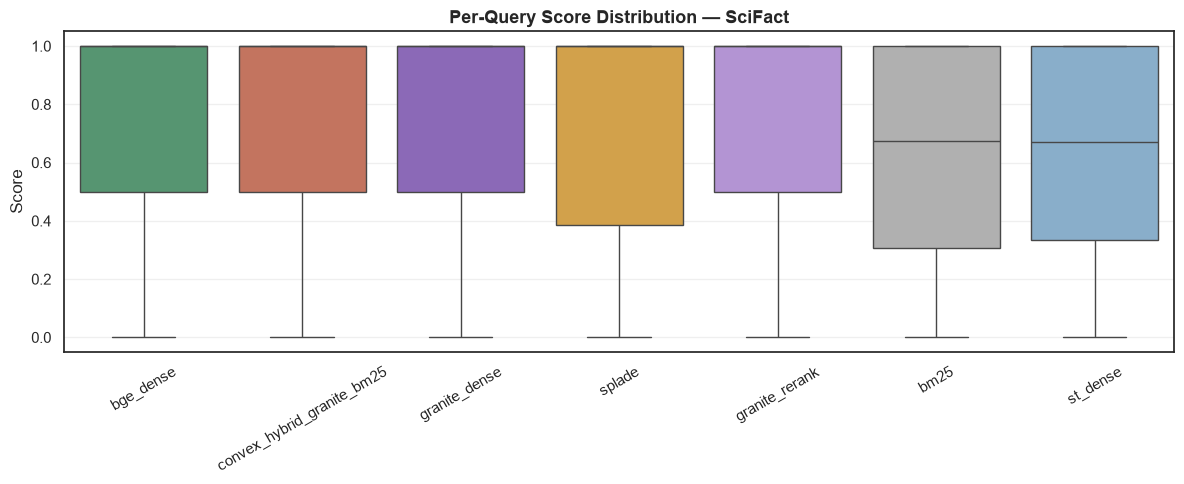

In [3]:
# Box plot: per-query score distribution, key retrievers, SciFact.
key_retrievers = [
    "granite_dense", "bm25", "st_dense", "bge_dense",
    "splade", "convex_hybrid_granite_bm25", "granite_rerank",
]
present = [r for r in key_retrievers if r in df_pq["retriever"].values]
df_sf = df_pq[(df_pq["dataset"] == "scifact") & (df_pq["retriever"].isin(present))]

fig, ax = plt.subplots(figsize=(12, 5))
order = df_sf.groupby("retriever")["score"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(
    data=df_sf, x="retriever", y="score", order=order,
    palette={
        "granite_dense": "#8a5cc4", "granite_rerank": "#b38add",
        "bge_dense": "#4c9f70", "st_dense": "#7eb0d5", "bm25": "#b0b0b0",
        "splade": "#e8a735", "convex_hybrid_granite_bm25": "#d46a4e",
    },
    flierprops={"markersize": 2, "alpha": 0.4}, ax=ax,
)
ax.set_title("Per-Query Score Distribution — SciFact", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

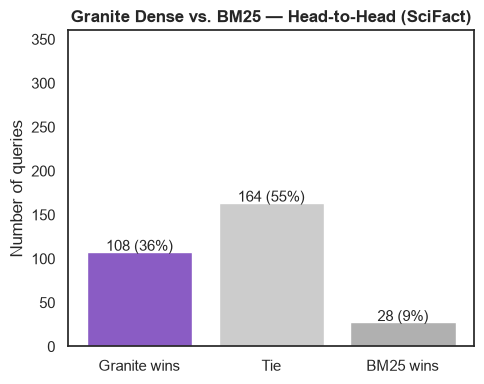

In [4]:
# Head-to-head: Granite Dense vs. BM25 on the same queries (SciFact).
df_wide = pd.read_csv(RESULTS_DIR / "scifact_per_query.csv")
wins = (df_wide["granite_dense"] > df_wide["bm25"]).sum()
ties = (df_wide["granite_dense"] == df_wide["bm25"]).sum()
losses = (df_wide["granite_dense"] < df_wide["bm25"]).sum()
total = len(df_wide)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Granite wins", "Tie", "BM25 wins"], [wins, ties, losses],
              color=["#8a5cc4", "#cccccc", "#b0b0b0"])
for bar, val in zip(bars, [wins, ties, losses]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val} ({val / total * 100:.0f}%)", ha="center", fontsize=11)
ax.set_title("Granite Dense vs. BM25 — Head-to-Head (SciFact)", fontsize=12, weight="bold")
ax.set_ylabel("Number of queries")
ax.set_ylim(0, total * 1.2)
plt.tight_layout()
plt.show()

### Per-Query Observations

- **Granite Dense wins most head-to-head comparisons** against BM25 — the advantage is not just a few outliers.
- **SPLADE and convex hybrids** show competitive median scores and tighter variance than pure dense or pure sparse.
- Reranking reduces variance further (granite_rerank has the tightest box).

---
## 2. RAG Results (real TriviaQA subset, HPC)

Quality of the retrieve-then-generate pipeline on TriviaQA.
Metrics: **answer EM** (exact match), **answer F1** (token overlap),
**answer cover** (recall of gold tokens), **context precision**,
**faithfulness**.

Data from `results/rag_trivia_subset.csv` (generated by `python -m eval.run_rag`).

In [5]:
df_rag = pd.read_csv(RESULTS_DIR / "rag_trivia_subset.csv")
print(f"RAG rows: {len(df_rag)}  |  retrievers: {df_rag['retriever'].unique().tolist()}")
print(f"Metrics: {[c for c in df_rag.columns if c != 'retriever']}")
df_rag

RAG rows: 3  |  retrievers: ['granite_dense', 'gte_dense', 'bm25']
Metrics: ['answer_em', 'answer_f1', 'answer_cover', 'context_precision', 'faithfulness']


,retriever,answer_em,answer_f1,answer_cover,context_precision,faithfulness
0,granite_dense,0.586,0.649619,0.698,0.3580,0.797283
1,gte_dense,0.570,0.635179,0.670,0.3755,0.807147
2,bm25,0.498,0.566084,0.608,0.3445,0.718586


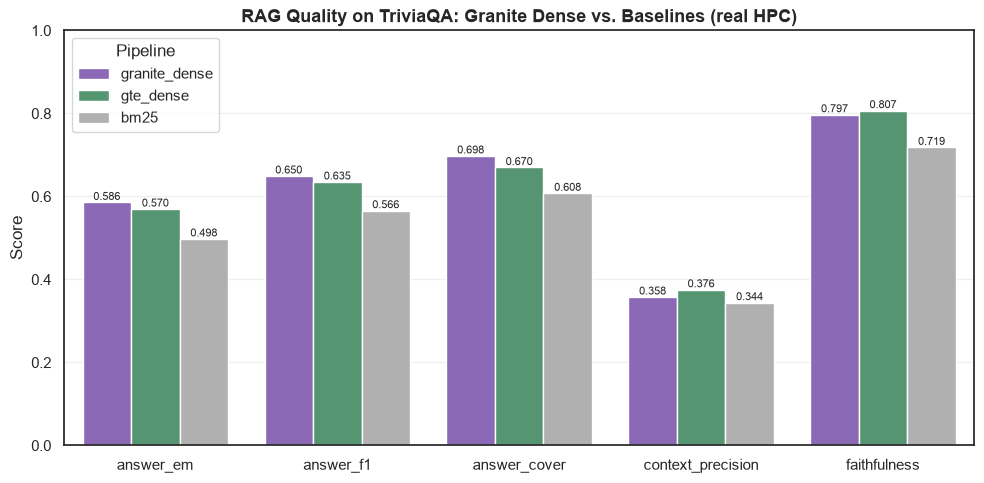

In [6]:
# RAG quality by retriever — all five metrics.
rag_metrics = [c for c in df_rag.columns if c != "retriever"]

df_rm = df_rag.melt(id_vars=["retriever"], value_vars=rag_metrics,
                     var_name="metric", value_name="score")

fig, ax = plt.subplots(figsize=(10, 5))
palette = {
    "granite_dense": "#8a5cc4",
    "gte_dense": "#4c9f70",
    "bm25": "#b0b0b0",
}
sns.barplot(data=df_rm, x="metric", y="score", hue="retriever",
            palette=palette, ax=ax)
ax.set_title("RAG Quality on TriviaQA: Granite Dense vs. Baselines (real HPC)",
             fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.legend(title="Pipeline", frameon=True)
ax.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.show()

### RAG Observations (real TriviaQA HPC data)

- **Granite Dense leads on answer quality**: EM = 0.586 vs. BM25 0.498 (+17.7%), F1 = 0.650 vs. 0.566.
- GTE Dense is competitive with Granite on answer F1 and faithfulness, but trails on exact match.
- **Context precision is low across the board** (~0.34–0.38) — the retrieved chunks often contain relevant info but the qrels-based precision metric is strict.
- **Faithfulness is high** (~0.72–0.81) — the generator rarely hallucinates outside the retrieved context.
- The retrieval-stage ranking (Granite > GTE > BM25) **carries through to answer quality** — better retrieval = better answers.

---
## Next Steps

- Re-run `python -m eval.run_rag --dataset trivia --retriever splade ...` to add SPLADE RAG rows.
- For aggregate benchmark and alpha curves see `01_visualize_heatmap.ipynb`.